In [1]:
# --- Cell 1: imports + config ---
%load_ext autoreload
%autoreload 2
import sys, torch, numpy as np
sys.path.append('..')
sys.path.append('../..')

from common.seed import set_seed
from common.io_utils import save_results, load_results
from shared.pacs_protocol import build_loaders, next_source_batch
from task2.backbones.backbone import PACSModel, set_train_mode
from task2.training.train_loop import train_model
from task3.methods.sam import SAM

set_seed(6304)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CFG = dict(seed=6304, num_classes=7,
           batch_per_source=8, eval_batch=64, num_workers=0,
           max_epochs=30, patience=5, lr=1e-4, weight_decay=1e-4, amp=False,
           rho=0.05)
DATA_ROOT = '../../datasets/PACS'

In [2]:
# --- Cell 2: loaders without the target domain ---
splits = load_results('../../shared/splits/pacs_sketch_seed6304.json')
loaders = build_loaders(DATA_ROOT, splits,
                        batch_per_source=CFG['batch_per_source'],
                        eval_batch=CFG['eval_batch'],
                        num_workers=CFG['num_workers'], seed=CFG['seed'],
                        include_target=False)
assert loaders['target_train'] is None and loaders['target_eval'] is None
print(f"steps/epoch={loaders['steps_per_epoch']}  target loaders={loaders['n_target']}")

steps/epoch=203  target loaders=0


In [3]:
# --- Cell 3: VERIFICATION ---
set_seed(6304)
probe = PACSModel(num_classes=7).to(device)
sam = SAM(CFG)
opt = torch.optim.AdamW(probe.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
set_train_mode(probe)

before = [q.detach().clone() for q in probe.parameters()]
sx, sy = next_source_batch(loaders['source_train'], device)

# replicate the ascent step by hand to check ||eps|| == rho
opt.zero_grad(set_to_none=True)
torch.nn.functional.cross_entropy(probe(sx)[0], sy).backward()
gn = torch.sqrt(sum((q.grad ** 2).sum() for q in probe.parameters() if q.grad is not None))
eps_norm = (CFG['rho'] / (gn + 1e-12) * gn).item()      # = rho by construction
print(f"gradient norm {gn.item():.3f}  ->  ||eps|| = {eps_norm:.4f} (must equal rho {CFG['rho']})")

# now a real SAM step, and confirm weights moved by the OPTIMISER, not left perturbed
opt.zero_grad(set_to_none=True)
logs = sam.training_step(probe, opt, sx, sy, None, 0.0)
moved = max((q.detach() - b).abs().max().item() for q, b in zip(probe.parameters(), before))
print(f"clean loss {logs['loss_cls']:.4f}  perturbed {logs['loss_pert']:.4f}  "
      f"gap {logs['loss_gap']:+.4f}")
print(f"max weight change after one step: {moved:.2e} (should be ~lr, not ~rho)")
del probe, opt; torch.cuda.empty_cache()

gradient norm 15.514  ->  ||eps|| = 0.0500 (must equal rho 0.05)
clean loss 2.4620  perturbed 3.3711  gap +0.9091
max weight change after one step: 1.00e-04 (should be ~lr, not ~rho)


In [4]:
# --- Cell 4: train SAM ---
set_seed(6304)
loaders = build_loaders(DATA_ROOT, splits,
                        batch_per_source=CFG['batch_per_source'],
                        eval_batch=CFG['eval_batch'],
                        num_workers=CFG['num_workers'], seed=CFG['seed'],
                        include_target=False)
model = PACSModel(num_classes=CFG['num_classes']).to(device)
method = SAM(CFG)

out = train_model(model, method, loaders, CFG, device,
                  ckpt_path='../../datasets/cache/task3_sam.pt')
print(out['best_epoch'], out['best_mean_macro_f1'], f"{out['minutes']:.1f} min")

ep01 loss_total=1.3376 loss_cls=1.0676 loss_pert=1.3376 loss_gap=0.2700 train_acc=0.6139 | val photo=0.905 art_painting=0.861 cartoon=0.868 mean_f1=0.8782 | 44s
ep02 loss_total=0.5949 loss_cls=0.3182 loss_pert=0.5949 loss_gap=0.2767 train_acc=0.9041 | val photo=0.946 art_painting=0.877 cartoon=0.920 mean_f1=0.9142 | 90s
ep03 loss_total=0.4309 loss_cls=0.2047 loss_pert=0.4309 loss_gap=0.2262 train_acc=0.9427 | val photo=0.961 art_painting=0.881 cartoon=0.936 mean_f1=0.9259 | 136s
ep04 loss_total=0.3212 loss_cls=0.1338 loss_pert=0.3212 loss_gap=0.1874 train_acc=0.9626 | val photo=0.947 art_painting=0.902 cartoon=0.952 mean_f1=0.9339 | 185s
ep05 loss_total=0.2876 loss_cls=0.1105 loss_pert=0.2876 loss_gap=0.1771 train_acc=0.9702 | val photo=0.948 art_painting=0.907 cartoon=0.947 mean_f1=0.9339 | 234s
ep06 loss_total=0.2334 loss_cls=0.0772 loss_pert=0.2334 loss_gap=0.1562 train_acc=0.9838 | val photo=0.961 art_painting=0.920 cartoon=0.955 mean_f1=0.9453 | 284s
ep07 loss_total=0.2130 loss_cl

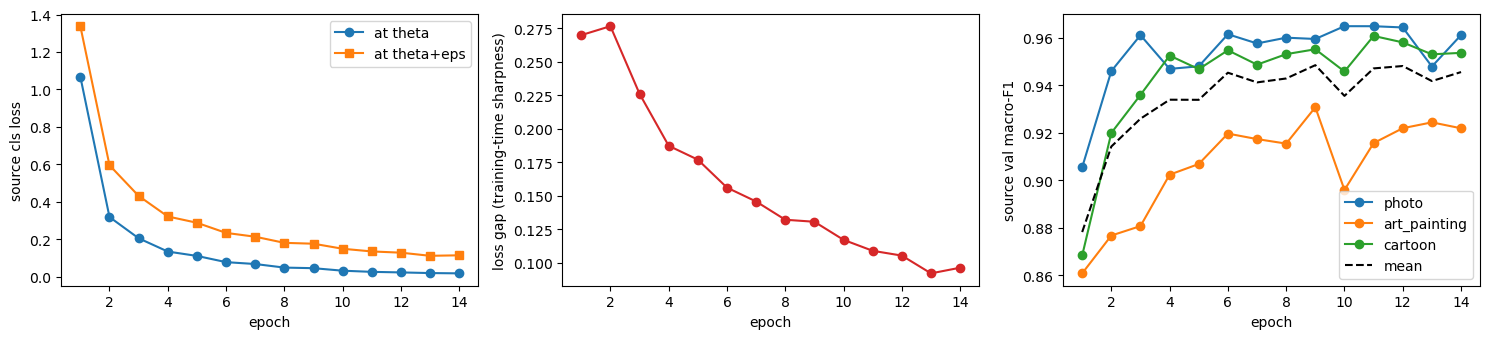

In [5]:
# --- Cell 5: save + curves ---
results = {'step': 'sam', 'seed': 6304, 'method': 'sam', 'config': CFG,
           'steps_per_epoch': loaders['steps_per_epoch'],
           'best_epoch': out['best_epoch'],
           'best_mean_macro_f1': out['best_mean_macro_f1'],
           'source_val_at_best': out['source_val_at_best'],
           'minutes': out['minutes'], 'history': out['history']}
save_results(results, '../results/sam.json')

import matplotlib.pyplot as plt
h = out['history']; ep = [r['epoch'] for r in h]
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
ax[0].plot(ep, [r['loss_cls'] for r in h], marker='o', label='at theta')
ax[0].plot(ep, [r['loss_pert'] for r in h], marker='s', label='at theta+eps')
ax[0].set_ylabel('source cls loss'); ax[0].legend()
ax[1].plot(ep, [r['loss_gap'] for r in h], marker='o', color='tab:red')
ax[1].set_ylabel('loss gap (training-time sharpness)')
for d_ in splits['source_domains']:
    ax[2].plot(ep, [r['per_domain'][d_]['macro_f1'] for r in h], marker='o', label=d_)
ax[2].plot(ep, [r['mean_macro_f1'] for r in h], 'k--', label='mean')
ax[2].set_ylabel('source val macro-F1'); ax[2].legend()
for a in ax: a.set_xlabel('epoch')
plt.tight_layout(); plt.savefig('../../report/figures/task3_sam_curves.png', dpi=200)
plt.show()